In [1]:
import numpy as np
import pandas as pd
import statistics
import seaborn as sns
import os
import subprocess
import shutil
import plotly.express as px
import sys
sys.path.append('/gpfs/commons/home/mgarbulowski/homic_package/src') 
from homic import file_readers, kraken2, process_data, make_plots
from collections import Counter
from scipy import stats
import matplotlib.pyplot as plt

homic package imported


In [2]:
def bacdict_to_bacdf(bac_dict, ntop, genus = False):
    if genus:
        s1 = bac_dict.index.to_list()
        s2 = [s.split()[0] for s in s1]

        bac_dict = bac_dict.set_axis(s2, axis='index')
        bac_dict = bac_dict.groupby(level=0).sum()
        bac_dict = bac_dict.sort_values(ascending=False)
        
    vals = bac_dict.values.tolist()
    inds = bac_dict.index.tolist()
    inds2 = [name if val >= vals[ntop-1] else "Other" for name, val in zip(inds, vals)]

    bacdf = pd.DataFrame({'abundance': vals},
                      index=inds2)
    
    bacdf = bacdf.groupby(bacdf.index).sum()
    bacdf = bacdf.div(bacdf.sum(axis=0), axis=1)
    return bacdf

In [3]:
# define paths
path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/Metagenomes"
db_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/ref_dbs/kraken/human_hg38"

# samples id 
#all_samps = ["KP005", "KP012", "KP013", "KP016", "KP024", 
#"KP025", "KP026", "KP027", "KP029","KP033","KP035","KP038","KP040","KP046","KP047","KP048"] # batch 1 + 3

all_samps = ["KP003","KP004","KP005","KP008","KP010","KP011","KP012",
         "KP013","KP016","KP021","KP024","KP025","KP026","KP027","KP029",
         "KP033","KP035","KP037","KP038","KP040","KP041","KP046","KP047","KP048","KP049","KP052"] # all batches

## loading metadata
meta = pd.read_csv("/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/metadata_kp.csv")
print(meta)
meta = meta.loc[meta['id'].isin(all_samps)] # keep only the sequenced ones
print(meta)
# intersecting with previous work
path1 = "/gpfs/commons/home/mgarbulowski/homic_package/files/65sp.txt"

with open(path1, "r") as f:
    bl_65sp = [line.strip() for line in f if line.strip()]
bl_65sp = [s.replace('[','').replace(']','') for s in bl_65sp]

# genera
gsg = bl_65sp
gsg = set([s.split()[0] for s in gsg])

       id  age   bmi  height  muac  fatpercent  fatfreemas       hiv  female  \
0   KP001   29  35.0   156.0  33.0        51.0        42.0  NEGATIVE       1   
1   KP002   43  38.0   161.0  39.0        51.0        49.0  NEGATIVE       1   
2   KP003   24  24.0   158.0  26.0        36.0        39.0  NEGATIVE       1   
3   KP004   26  24.0   158.0  26.0        29.0        42.0  NEGATIVE       1   
4   KP005   22  23.0   175.0  30.0        16.0        60.0  NEGATIVE       0   
5   KP006   33  23.0   162.0  25.0        18.0        50.0  POSITIVE       0   
6   KP007   28  27.0   153.0  30.0        38.0        39.0  NEGATIVE       1   
7   KP008   28  20.0   168.0  27.0        15.0        48.0  NEGATIVE       0   
8   KP009   30  22.0   164.0  26.0        19.0        48.0  NEGATIVE       0   
9   KP010   24  22.0   162.0  25.0        16.0        49.0  NEGATIVE       0   
10  KP011   29  29.0   148.0  31.0        36.0        40.0  NEGATIVE       1   
11  KP012   34  20.0   154.0  23.0      

In [4]:
## replicates analysis

#path_main = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/replicates_analysis/blastn_refseq/"
#path_main2 = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/replicates_analysis/"
#
#samps_id1 = ["B1_KP027"]
#samps_id2 = ["B3_KP027"]
#samps_id3 = ["B5_KP027"]
#samps_id4 = ["B6_KP027"]
#
#b1_01, b1_005, b1_001, df_fls1 = process_data.select_taxa(path_main, samps_id1, taxa_level="species", db="rs")
#b3_01, b3_005, b3_001, df_fls3 = process_data.select_taxa(path_main, samps_id2, taxa_level="species", db="rs")
#b5_01, b5_005, b5_001, df_fls5 = process_data.select_taxa(path_main, samps_id3, taxa_level="species", db="rs")
#b6_01, b6_005, b6_001, df_fls6 = process_data.select_taxa(path_main, samps_id4, taxa_level="species", db="rs")
#
#
#ntop = 10
### species level female low SES
#df_b1_01 = bacdict_to_bacdf(b1_01, ntop)
### species level female high SES
#df_b3_01 = bacdict_to_bacdf(b3_01, ntop)
### species level male low SES
#df_b5_01 = bacdict_to_bacdf(b5_01, ntop)
### species level male high SES
#df_b6_01 = bacdict_to_bacdf(b6_01, ntop)
#
#nam1="batch 1"
#nam2="batch 2"
#nam3="batch 3"
#nam4="batch 4"
#
#data_list = [df_b1_01, df_b3_01, df_b5_01, df_b6_01]
#bar_subtitles = [nam1, nam2, nam3, nam4]
#fig = make_plots.relative_abundance_four(data_list, bar_subtitles, common_legend=True, clegend_nrows=6)
#fig.savefig(path_main2 + "/figs/abundance_species_01_RefSeq_kp027_replicates.png", dpi=300, bbox_inches='tight')

In [5]:
## replicates analysis

#path_main = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/replicates_analysis/blastn_refseq/"
#
#samps_id1 = ["B1_KP027"]
#samps_id2 = ["B3_KP027"]
#samps_id3 = ["B5_KP027"]
#samps_id4 = ["B6_KP027"]
#
#b1_01, b1_005, b1_001, df_fls1 = process_data.select_taxa(path_main, samps_id1, taxa_level="genus", db="rs")
#b3_01, b3_005, b3_001, df_fls3 = process_data.select_taxa(path_main, samps_id2, taxa_level="genus", db="rs")
#b5_01, b5_005, b5_001, df_fls5 = process_data.select_taxa(path_main, samps_id3, taxa_level="genus", db="rs")
#b6_01, b6_005, b6_001, df_fls6 = process_data.select_taxa(path_main, samps_id4, taxa_level="genus", db="rs")
#
#ntop = 10
### species level female low SES
#df_b1_01 = bacdict_to_bacdf(b1_01, ntop)
### species level female high SES
#df_b3_01 = bacdict_to_bacdf(b3_01, ntop)
### species level male low SES
#df_b5_01 = bacdict_to_bacdf(b5_01, ntop)
### species level male high SES
#df_b6_01 = bacdict_to_bacdf(b6_01, ntop)
#
#nam1="batch 1"
#nam2="batch 2"
#nam3="batch 3"
#nam4="batch 4"
#
#data_list = [df_b1_01, df_b3_01, df_b5_01, df_b6_01]
#bar_subtitles = [nam1, nam2, nam3, nam4]
#fig = make_plots.relative_abundance_four(data_list, bar_subtitles, common_legend=True, clegend_nrows=6)
#fig.savefig(path_main2 + "/figs/abundance_genus_01_RefSeq_kp027_replicates.png", dpi=300, bbox_inches='tight')

In [6]:
#from scipy.spatial.distance import pdist, squareform
#import seaborn as sns
#import matplotlib.pyplot as plt
#
#b1_01, b1_005, b1_001, df_fls1 = process_data.select_taxa(path_main, samps_id1, taxa_level="species", db="rs")
#b3_01, b3_005, b3_001, df_fls3 = process_data.select_taxa(path_main, samps_id2, taxa_level="species", db="rs")
#b5_01, b5_005, b5_001, df_fls5 = process_data.select_taxa(path_main, samps_id3, taxa_level="species", db="rs")
#b6_01, b6_005, b6_001, df_fls6 = process_data.select_taxa(path_main, samps_id4, taxa_level="species", db="rs")
#
#listed_data = [df_fls1, df_fls3, df_fls5, df_fls6]
#counts = [Counter(df["species"]) for df in listed_data]
#data_names = ["batch 1", "batch 2", "batch 3", "batch 4"]
#
## create DataFrame from all counts
#df = pd.DataFrame(counts).fillna(0).astype(int)
#df = df.T
#df.columns = data_names
#
#
#df["batch 1"] = (df["batch 1"]/df["batch 1"].sum()) 
#df["batch 2"] = (df["batch 2"]/df["batch 2"].sum()) 
#df["batch 3"] = (df["batch 3"]/df["batch 3"].sum()) 
#df["batch 4"] = (df["batch 4"]/df["batch 4"].sum()) 
#df = df.T
#
## Compute pairwise bray-curtis distances
#bray = pdist(df, metric="braycurtis")
#
## Convert to a square matrix
#bray_matrix = pd.DataFrame(
#    squareform(bray), 
#    index=df.index, 
#    columns=df.index
#)
#
### genus
#countsg = [Counter(df["genus"]) for df in listed_data]
#
## create DataFrame from all counts
#dfg = pd.DataFrame(countsg).fillna(0).astype(int)
#dfg = dfg.T
#dfg.columns = data_names
#
#
#dfg["batch 1"] = (dfg["batch 1"]/dfg["batch 1"].sum()) 
#dfg["batch 2"] = (dfg["batch 2"]/dfg["batch 2"].sum()) 
#dfg["batch 3"] = (dfg["batch 3"]/dfg["batch 3"].sum())
#dfg["batch 4"] = (dfg["batch 4"]/dfg["batch 4"].sum()) 
#dfg = dfg.T
#bray_genus = pdist(dfg, metric="braycurtis")
#
## Convert to a square matrix
#bray_matrix_genus = pd.DataFrame(
#    squareform(bray_genus), 
#    index=dfg.index, 
#    columns=dfg.index
#)
#
## Optional: create labels for rows/columns
#labels = ['A', 'B', 'C', 'D', 'E']
#
## Create subplots: 1 row, 2 columns
#fig, axes = plt.subplots(1, 2, figsize=(12, 5))
#
## Plot first heatmap
#sns.heatmap(bray_matrix, ax=axes[0], annot=True, fmt=".2f", cmap="cividis")
#axes[0].set_title("Bray–Curtis Distance for species abundance")
#axes[0].text(-0.3, 1.05, 'A', transform=axes[0].transAxes, 
#             fontsize=20, fontweight='bold', va='top', ha='right')
#
## Plot second heatmap
#sns.heatmap(bray_matrix_genus, ax=axes[1], annot=True, fmt=".2f", cmap="cividis")
#axes[1].set_title("Bray–Curtis Distance for genera abundance")
#axes[1].text(-0.3, 1.05, 'B', transform=axes[1].transAxes, 
#             fontsize=20, fontweight='bold', va='top', ha='right')
#
#plt.tight_layout()
#plt.show()
#
#
#fig.savefig(path_main2 + "/figs/bray_curtis_abundances_kp027_batches.png", dpi=300, bbox_inches="tight")  # PNG format
#


In [7]:
path_blast = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/contigs_all_x4/blastn_refseq/"

### female low SES ###
meta_fls = meta[(meta["female"] == 1) & (meta["highSES"] == 0)]
samps_ids_fls = meta_fls["id"]
samps_len_fls = len(samps_ids_fls)
print("Sample length female low SES: " + str(samps_len_fls))
fls01, fls005, fls001, df_fls = process_data.select_taxa(path_blast, samps_ids_fls, taxa_level="species", db="rs")

### male low SES ###
meta_mls = meta[(meta["female"] == 0) & (meta["highSES"] == 0)]
samps_ids_mls = meta_mls["id"]
samps_len_mls = len(samps_ids_mls)
print("Sample length male low SES: " + str(samps_len_mls))
mls01, mls005, mls001, df_mls = process_data.select_taxa(path_blast, samps_ids_mls, taxa_level="species", db="rs")

### female high SES ###
meta_fhs = meta[(meta["female"] == 1) & (meta["highSES"] == 1)]
samps_ids_fhs = meta_fhs["id"]
samps_len_fhs = len(samps_ids_fhs)
print("Sample length female high SES: " + str(samps_len_fhs))
fhs01, fhs005, fhs001, df_fhs = process_data.select_taxa(path_blast, samps_ids_fhs, taxa_level="species", db="rs")

### male high SES ###
meta_mhs = meta[(meta["female"] == 0) & (meta["highSES"] == 1)]
samps_ids_mhs = meta_mhs["id"]
samps_len_mhs = len(samps_ids_mhs)
print("Sample length male high SES: " + str(samps_len_mhs))
mhs01, mhs005, mhs001, df_mhs = process_data.select_taxa(path_blast, samps_ids_mhs, taxa_level="species", db="rs")

## severe/moderate EED
samps_ids_smeed = ["KP003","KP004","KP005","KP013","KP016","KP021","KP038"]
samps_len_smeed = len(samps_ids_smeed)
print("Sample length s+m EED: " + str(samps_len_smeed))
smeed01, smeed005, smeed001, df_smeed = process_data.select_taxa(path_blast, samps_ids_smeed, taxa_level="species", db="rs")

## mild EED
samps_ids_meed = ["KP008","KP010","KP011","KP012","KP024"]
samps_len_meed = len(samps_ids_meed)
print("Sample length mild EED: " + str(samps_len_meed))
meed01, meed005, meed001, df_meed = process_data.select_taxa(path_blast, samps_ids_meed, taxa_level="species", db="rs")


Sample length female low SES: 9
Sample length male low SES: 7
Sample length female high SES: 8
Sample length male high SES: 2
Sample length s+m EED: 7
Sample length mild EED: 5


In [8]:
main_path = "/gpfs/commons/home/mgarbulowski/016_proj_shm/metagenomes_lib/contigs_all_x4"
# female low SES
print("female, low SES")
print("0.1%")
print(len(fls01))

# female high SES
print("female, high SES")
print("0.1%")
print(len(fhs01))


#print("")
#print("0.05%")
#print(len(fls005))
#print("")
#print("0.01%")
#print(len(fls001))

# male low SES
print("")
print("male, low SES")
print("0.1%")
print(len(mls01))

# male high SES
print("")
print("male, high SES")
print("0.1%")
print(len(mhs01))

### save to files
# female low SES
spec_lst = list(fls01.keys())
with open(main_path + "/species_01%_female_lowSES.txt", "w") as f:
    for item in spec_lst:
        f.write(f"{item}\n")

spec_lst2 = list(mls01.keys())
with open(main_path + "/species_01%_male_lowSES.txt", "w") as f:
    for item in spec_lst2:
        f.write(f"{item}\n")

spec_lst3 = list(fhs01.keys())
with open(main_path + "/species_01%_female_highSES.txt", "w") as f:
    for item in spec_lst3:
        f.write(f"{item}\n")

spec_lst4 = list(mhs01.keys())
with open(main_path + "/species_01%_male_highSES.txt", "w") as f:
    for item in spec_lst4:
        f.write(f"{item}\n")

###
spec_lst5 = list(smeed01.keys())
with open(main_path + "/species_01%_mod+sev_EED.txt", "w") as f:
    for item in spec_lst5:
        f.write(f"{item}\n")

spec_lst6 = list(meed01.keys())
with open(main_path + "/species_01%_mild_EED.txt", "w") as f:
    for item in spec_lst6:
        f.write(f"{item}\n")


#print("")
#print("0.05%")
#print(len(mls005))
#print("")
#print("0.01%")
#print(len(mls001))

# (>0.1%, >0.05% and >0.01% corresponding to 65, 121 and 419 species, respectively)


print("common species with previous work (female lSES): ")
print(str(round(len(list(set(list(fls01.index)).intersection(bl_65sp)))/len(bl_65sp) * 100)) + "%" + " overlap")
print("")
print("common species with previous work (female hSES): ")
print(str(round(len(list(set(list(fhs01.index)).intersection(bl_65sp)))/len(bl_65sp) * 100)) + "%" + " overlap")
print("common species with previous work (male lSES): ")
print(str(round(len(list(set(list(mls01.index)).intersection(bl_65sp)))/len(bl_65sp) * 100)) + "%" + " overlap")
print("")
print("common species with previous work (male hSES): ")
print(str(round(len(list(set(list(mhs01.index)).intersection(bl_65sp)))/len(bl_65sp) * 100)) + "%" + " overlap")


female, low SES
0.1%
125
female, high SES
0.1%
134

male, low SES
0.1%
120

male, high SES
0.1%
97
common species with previous work (female lSES): 
18% overlap

common species with previous work (female hSES): 
22% overlap
common species with previous work (male lSES): 
17% overlap

common species with previous work (male hSES): 
9% overlap


In [9]:
import pandas as pd
from bacdive import BacdiveClient

# Species list
species_list = list(set(list(smeed01.keys())) - set(list(meed01.keys())))

client = BacdiveClient()
client.setSearchType("exact")

def extract_field_safe(obj, key_path):
    """
    Recursively extract a field from nested dicts/lists.
    key_path: list of keys to traverse.
    Returns the first found value or None.
    """
    if obj is None:
        return None
    if not key_path:
        return None
    key = key_path[0]

    if isinstance(obj, dict):
        val = obj.get(key)
        if len(key_path) == 1:
            return val
        else:
            return extract_field_safe(val, key_path[1:])
    elif isinstance(obj, list):
        # iterate over list elements, return first non-None
        for item in obj:
            val = extract_field_safe(item, key_path)
            if val is not None:
                return val
        return None
    return None

# Collect all raw strain info
all_records = []

for name in species_list:
    print(f"Searching BacDive for: {name}")
    client.search(taxonomy=name)
    raw_results = list(client.retrieve())
    
    if not raw_results:
        all_records.append({
            "species": name,
            "BacDive_ID": None,
            "keywords": None,
            "description": None,
            "culture_collection": None,
            "sample_type": None,
            "geographic_location": None,
            "country": None,
            "biosafety_level": None,
            "human_pathogen": None,
            "pathogen_flag": "No data"
        })
        continue

    for strain in raw_results:
        record = {"species": name}

        # Extract fields safely
        record["BacDive_ID"] = extract_field_safe(strain, ["General", "BacDive-ID"])
        record["keywords"] = extract_field_safe(strain, ["General", "keywords"])
        record["description"] = extract_field_safe(strain, ["General", "description"])
        record["culture_collection"] = extract_field_safe(strain, ["Literature", "culture collection no."])
        record["sample_type"] = extract_field_safe(strain, ["Isolation, sampling and environmental information", "isolation", "sample type"])
        record["geographic_location"] = extract_field_safe(strain, ["Isolation, sampling and environmental information", "isolation", "geographic location"])
        record["country"] = extract_field_safe(strain, ["Isolation, sampling and environmental information", "isolation", "country"])
        record["biosafety_level"] = extract_field_safe(strain, ["Interaction and safety", "risk assessment", "biosafety level"])
        record["human_pathogen"] = extract_field_safe(strain, ["Interaction and safety", "risk assessment", "pathogenicity human"])

        all_records.append(record)

# Convert to DataFrame
df = pd.DataFrame(all_records)

# Flatten by species
def merge_series(series):
    """Merge lists or unique strings into a single string, ignore NaN"""
    series = series.dropna()
    values = set()
    for val in series:
        if isinstance(val, list):
            values.update(val)
        else:
            values.add(str(val))
    return "; ".join(values) if values else None

flat_df = df.groupby("species").agg({
    "BacDive_ID": merge_series,
    "keywords": merge_series,
    "description": merge_series,
    "culture_collection": merge_series,
    "sample_type": merge_series,
    "geographic_location": merge_series,
    "country": merge_series,
    "biosafety_level": lambda x: max([int(b) for b in x.dropna() if str(b).isdigit()]) if any(x.dropna()) else None,
    "human_pathogen": merge_series
}).reset_index()

# Recompute pathogen_flag for flat species overview
def compute_pathogen_flag(row):
    keywords = row["keywords"] or ""
    human_pathogen = row["human_pathogen"] or ""
    keywords_str = keywords.lower() if isinstance(keywords, str) else ""
    if "pathogen" in keywords_str or "yes" in str(human_pathogen).lower():
        return "Potential pathogen"
    else:
        return "Probably non-pathogenic"

flat_df["pathogen_flag"] = flat_df.apply(compute_pathogen_flag, axis=1)


# Show result
print(flat_df)


# Save to CSV if needed
flat_df.to_csv(main_path + "/bacdive_mod+sev_EED_unique.csv", index=False)


Searching BacDive for: Wujia chipingensis
Your search did not receive any results.
Searching BacDive for: Eshraghiella crossota
Searching BacDive for: Dialister massiliensis
Searching BacDive for: Bacteroides fragilis
Searching BacDive for: Lactobacillus delbrueckii
Searching BacDive for: Phocaeicola dorei
Searching BacDive for: Megamonas funiformis
Searching BacDive for: Roseburia faecis
Searching BacDive for: Parabacteroides faecalis
Searching BacDive for: Simiaoa sunii
Your search did not receive any results.
Searching BacDive for: Lachnospira eligens
Searching BacDive for: Shigella sonnei
Searching BacDive for: Phoenicibacter congonensis
Your search did not receive any results.
Searching BacDive for: Bacteroides xylanisolvens
Searching BacDive for: Lactobacillus leichmannii
Searching BacDive for: Waltera acetigignens
Searching BacDive for: Weissella confusa
Searching BacDive for: Enterococcus hirae
Searching BacDive for: Shigella flexneri
Searching BacDive for: Phocaeicola plebeius

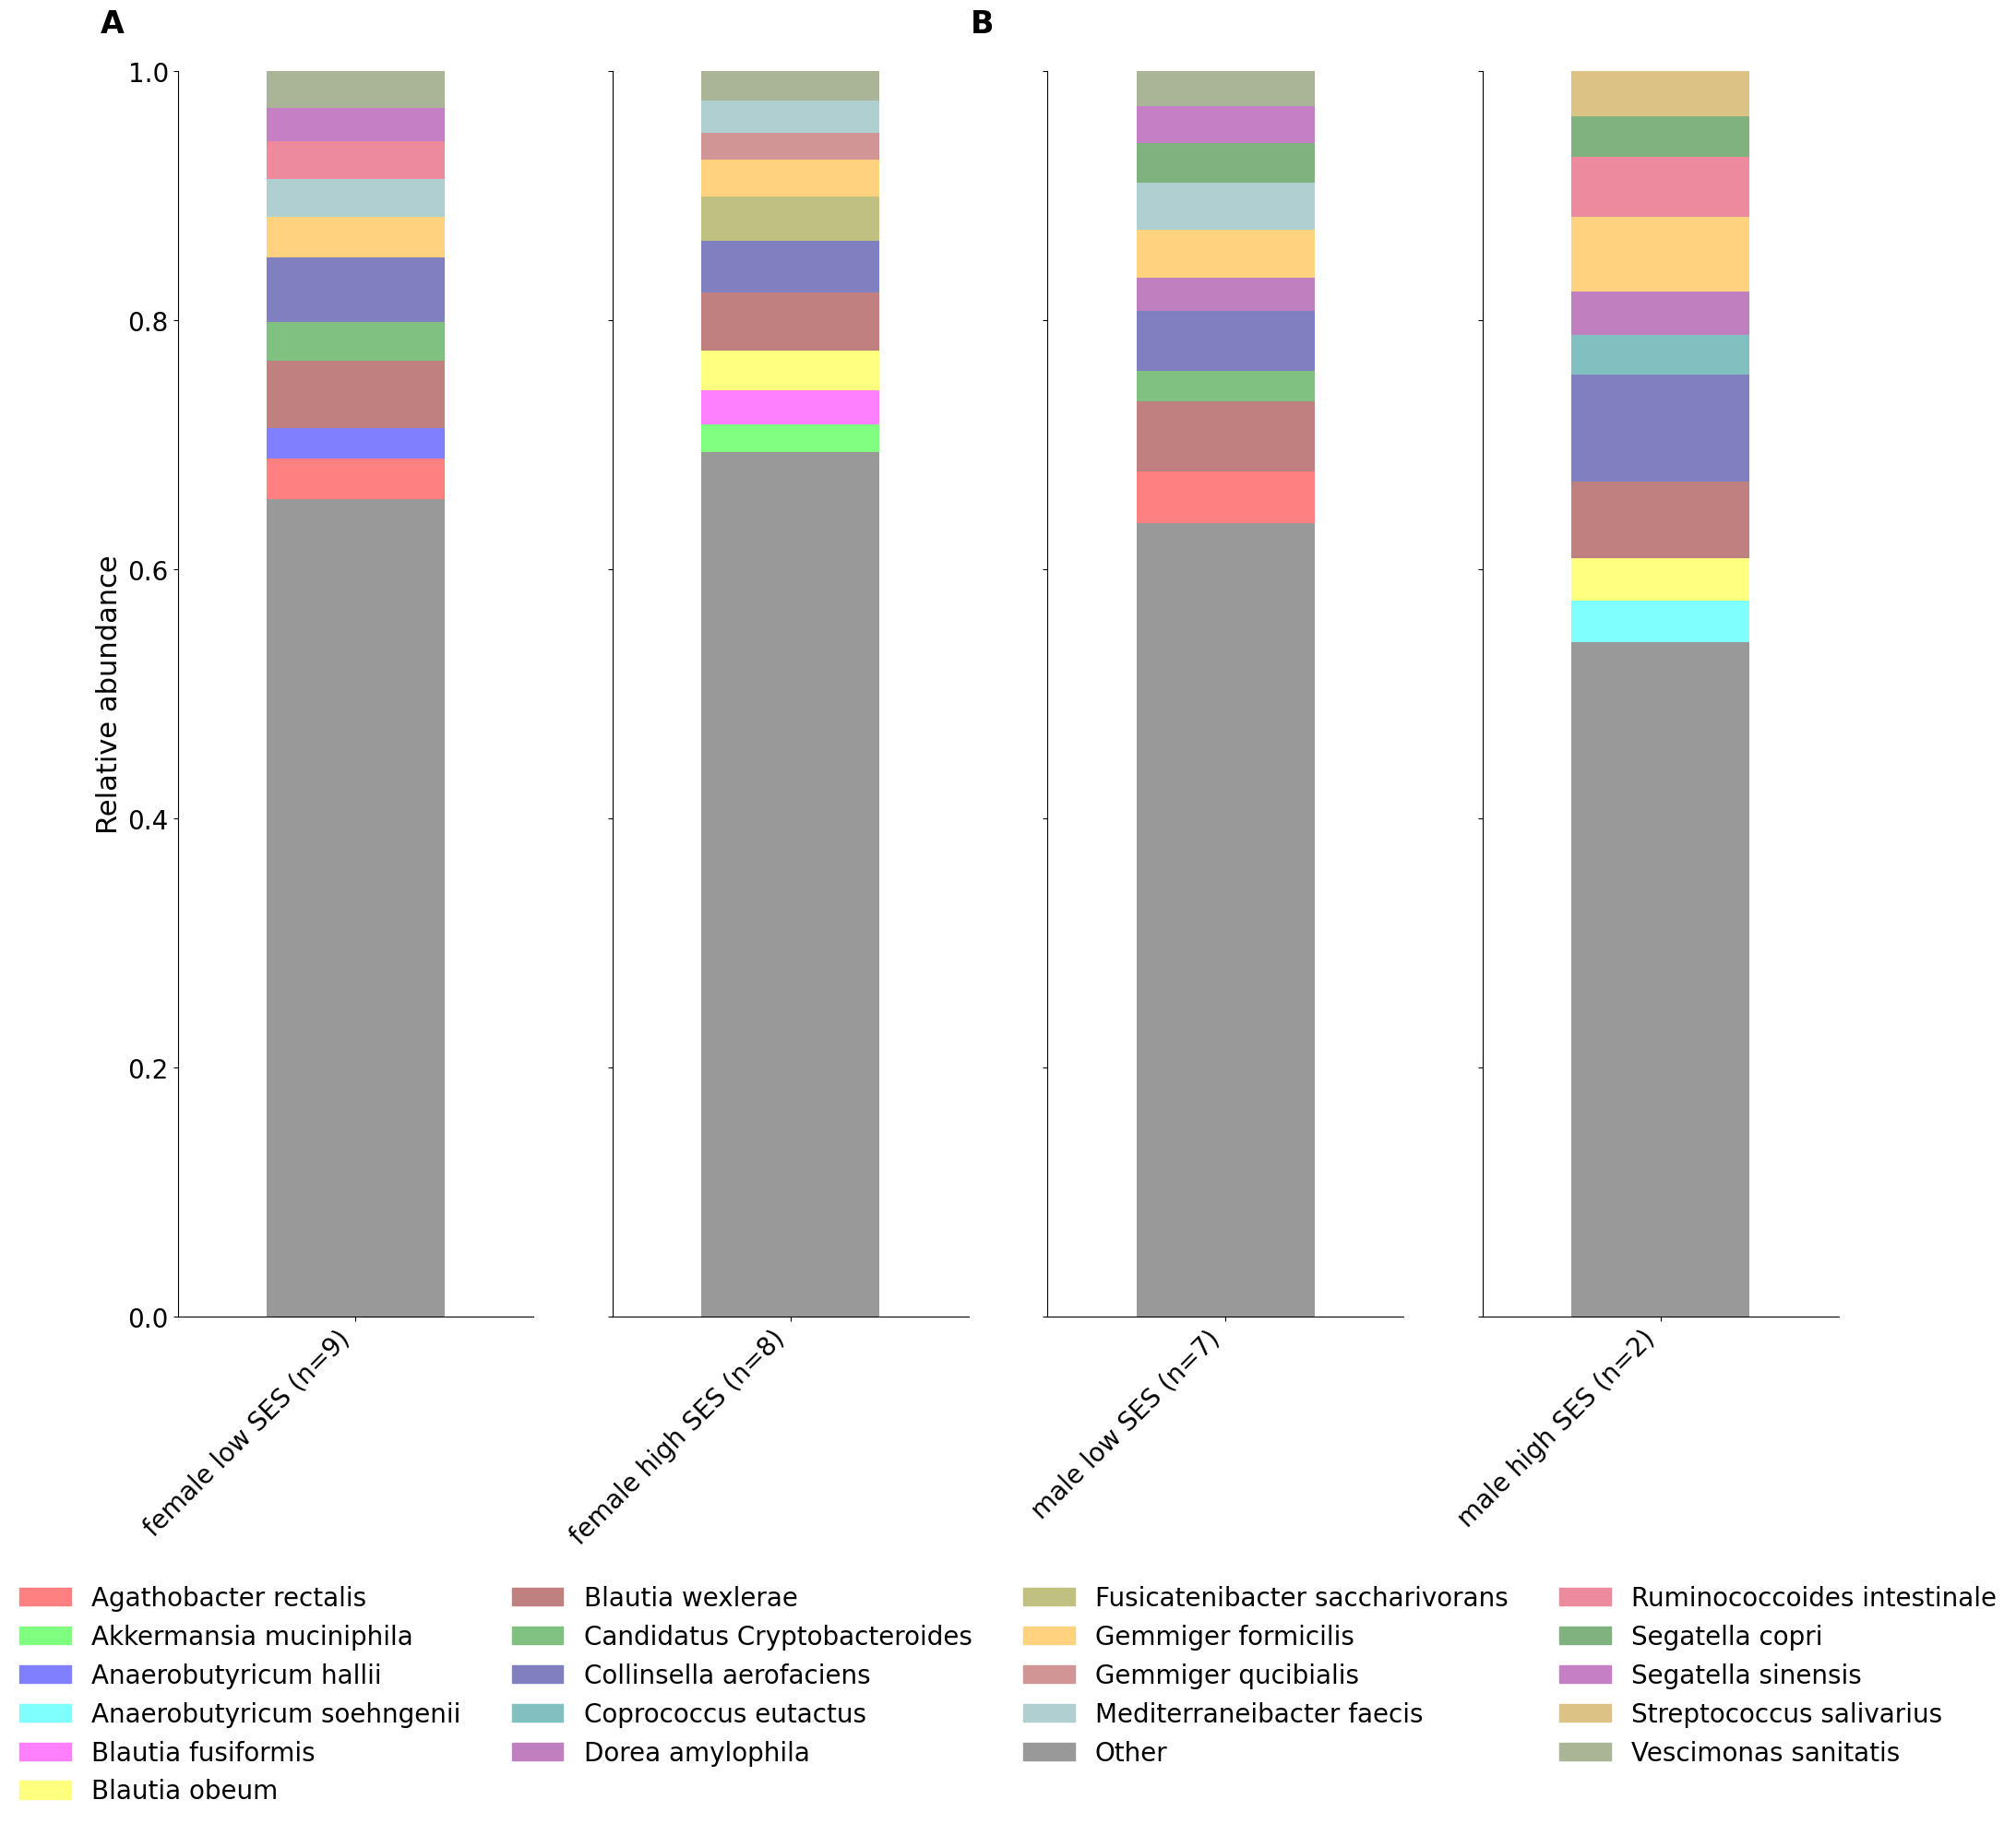

In [10]:
ntop = 10
## species level female low SES
df_fls01 = bacdict_to_bacdf(fls01, ntop)
## species level female high SES
df_fhs01 = bacdict_to_bacdf(fhs01, ntop)
## species level male low SES
df_mls01 = bacdict_to_bacdf(mls01, ntop)
## species level male high SES
df_mhs01 = bacdict_to_bacdf(mhs01, ntop)

nam1="female low SES"+" (n="+str(samps_len_fls)+")"
nam2="female high SES"+" (n="+str(samps_len_fhs)+")"
nam3="male low SES"+" (n="+str(samps_len_mls)+")"
nam4="male high SES"+" (n="+str(samps_len_mhs)+")"

data_list = [df_fls01, df_fhs01, df_mls01, df_mhs01]
bar_subtitles = [nam1,nam2,nam3,nam4]
fig = make_plots.relative_abundance_four(data_list, bar_subtitles, common_legend=True, clegend_nrows=6)
fig.savefig(main_path + "/figs/abundance_species_mf_lSES_hSES_01_RefSeq.png", dpi=300, bbox_inches='tight')


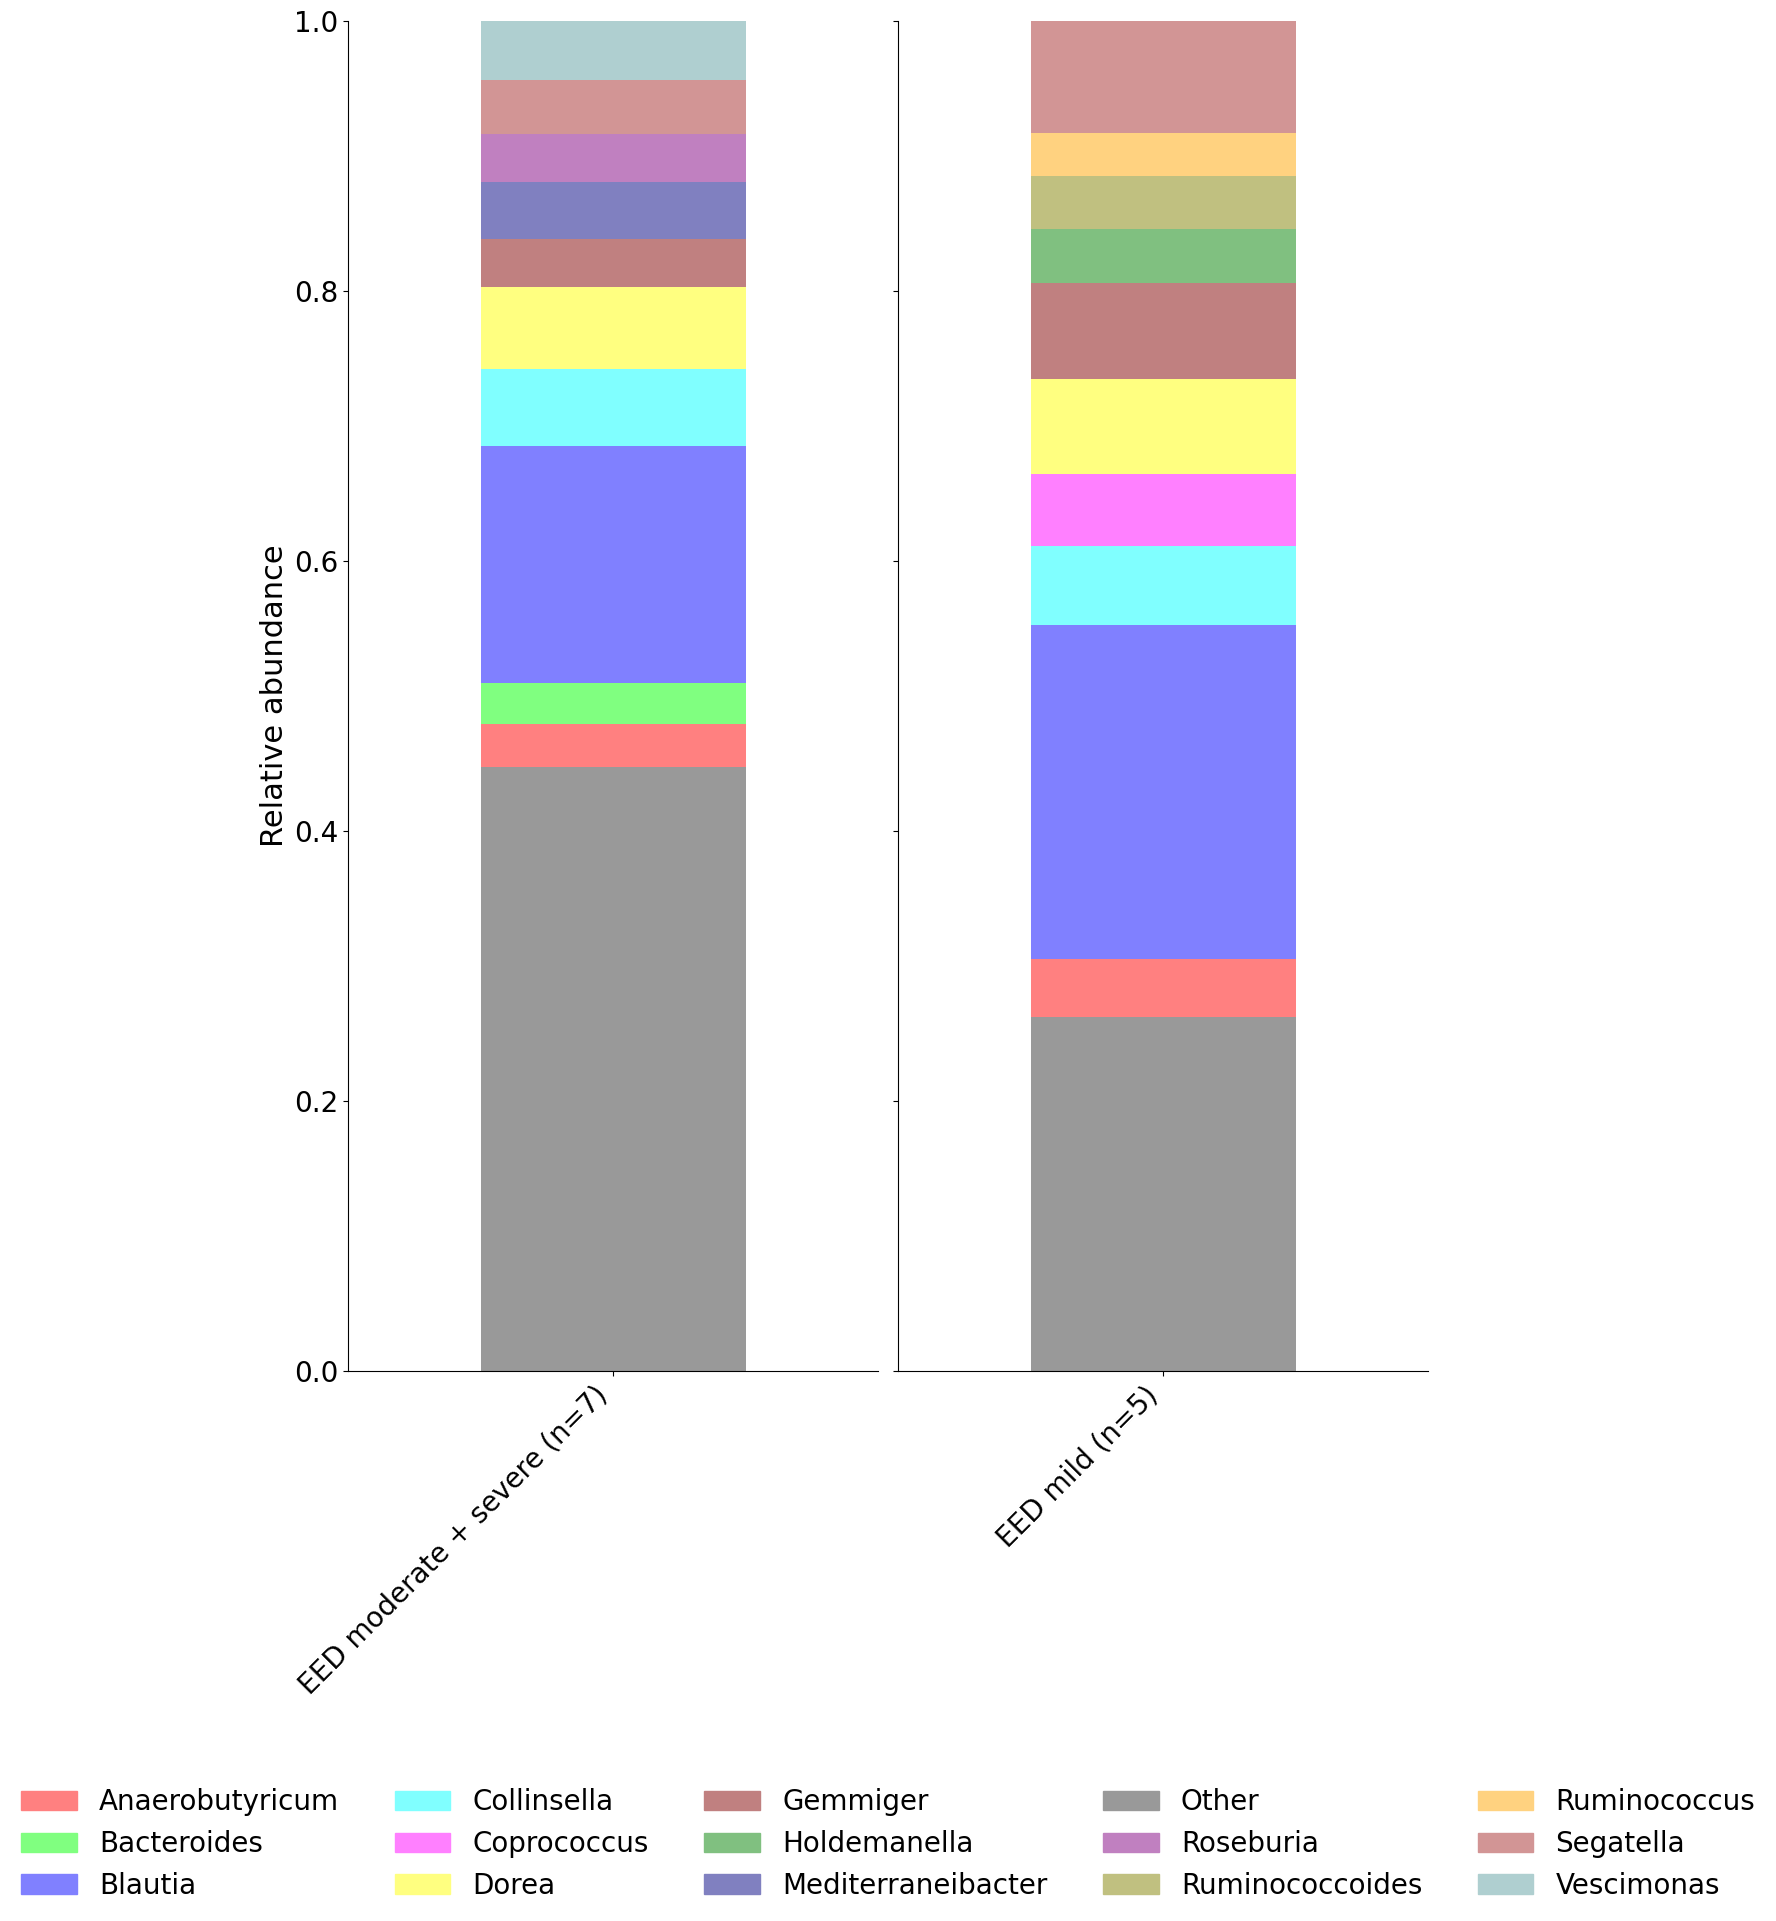

In [11]:
ntop = 10
## species level female low SES
df_smeed01 = bacdict_to_bacdf(smeed01, ntop, genus = True)
## species level female high SES
df_meed01 = bacdict_to_bacdf(meed01, ntop, genus = True)
## species level male low SES
df_mls01 = bacdict_to_bacdf(mls01, ntop, genus = True)
## species level male high SES
df_mhs01 = bacdict_to_bacdf(mhs01, ntop, genus = True)

nam1="EED moderate + severe"+" (n="+str(samps_len_smeed)+")"
nam2="EED mild"+" (n="+str(samps_len_meed)+")"
nam3="male low SES"+" (n="+str(samps_len_mls)+")"
nam4="male high SES"+" (n="+str(samps_len_mhs)+")"

data_list = [df_smeed01, df_meed01]#, df_mls01, df_mhs01]
bar_subtitles = [nam1,nam2]#,nam3,nam4]
#fig = make_plots.relative_abundance_four(data_list, bar_subtitles, common_legend=True, clegend_nrows=3)
fig = make_plots.relative_abundance_two(data_list, bar_subtitles, common_legend=True, clegend_nrows=3)
fig.savefig(main_path + "/figs/abundance_genus_EED_01_RefSeq.png", dpi=300, bbox_inches='tight')


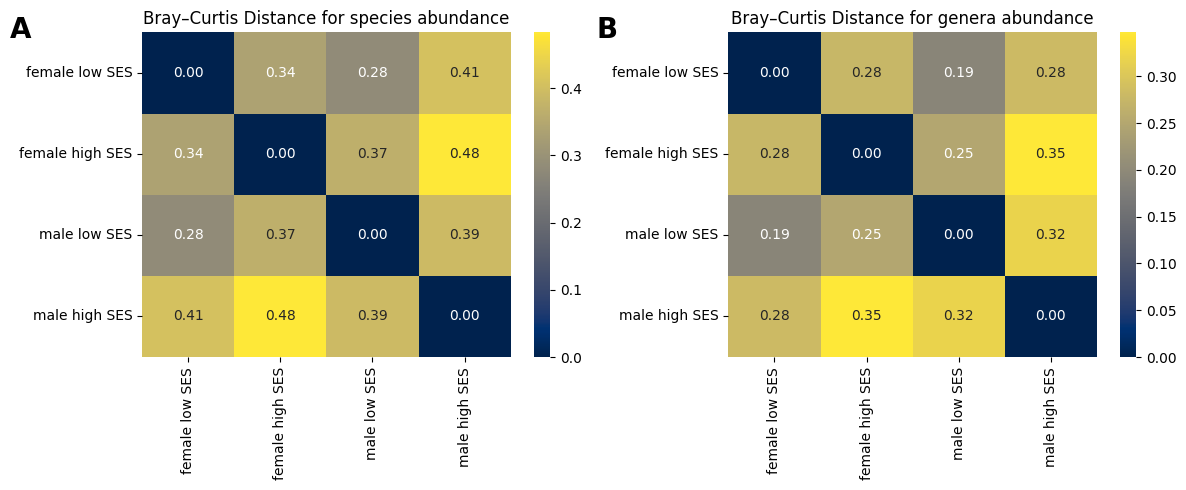

In [12]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt

listed_data = [df_fls, df_fhs, df_mls, df_mhs]
counts = [Counter(df["species"]) for df in listed_data]
data_names = ["female low SES", "female high SES", "male low SES", "male high SES"]

# create DataFrame from all counts
df = pd.DataFrame(counts).fillna(0).astype(int)
df = df.T
df.columns = data_names


df['female low SES'] = (df['female low SES']/df['female low SES'].sum()) 
df['female high SES'] = (df['female high SES']/df['female high SES'].sum()) 
df['male low SES'] = (df['male low SES']/df['male low SES'].sum()) 
df['male high SES'] = (df['male high SES']/df['male high SES'].sum()) 
df = df.T

# Compute pairwise bray-curtis distances
bray = pdist(df, metric="braycurtis")

# Convert to a square matrix
bray_matrix = pd.DataFrame(
    squareform(bray), 
    index=df.index, 
    columns=df.index
)

## genus
countsg = [Counter(df["genus"]) for df in listed_data]

# create DataFrame from all counts
dfg = pd.DataFrame(countsg).fillna(0).astype(int)
dfg = dfg.T
dfg.columns = data_names


dfg['female low SES'] = (dfg['female low SES']/dfg['female low SES'].sum()) 
dfg['female high SES'] = (dfg['female high SES']/dfg['female high SES'].sum()) 
dfg['male low SES'] = (dfg['male low SES']/dfg['male low SES'].sum()) 
dfg['male high SES'] = (dfg['male high SES']/dfg['male high SES'].sum()) 
dfg = dfg.T
bray_genus = pdist(dfg, metric="braycurtis")

# Convert to a square matrix
bray_matrix_genus = pd.DataFrame(
    squareform(bray_genus), 
    index=dfg.index, 
    columns=dfg.index
)

# Optional: create labels for rows/columns
labels = ['A', 'B', 'C', 'D', 'E']

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot first heatmap
sns.heatmap(bray_matrix, ax=axes[0], annot=True, fmt=".2f", cmap="cividis")
axes[0].set_title("Bray–Curtis Distance for species abundance")
axes[0].text(-0.3, 1.05, 'A', transform=axes[0].transAxes, 
             fontsize=20, fontweight='bold', va='top', ha='right')

# Plot second heatmap
sns.heatmap(bray_matrix_genus, ax=axes[1], annot=True, fmt=".2f", cmap="cividis")
axes[1].set_title("Bray–Curtis Distance for genera abundance")
axes[1].text(-0.3, 1.05, 'B', transform=axes[1].transAxes, 
             fontsize=20, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.show()


fig.savefig(main_path + "/figs/bray_curtis_heatmap_of_abundances.png", dpi=300, bbox_inches="tight")  # PNG format

